# Data Understanding & Preparation - Heart Diagnoses (Admission Level)

## Overview

This notebook extracts clinical features from the **Heart Diagnoses** table at the **admission level** (one row per hadm_id). Features are created using subject_id and hadm_id as primary identifiers, without patient-level aggregation.


## Setup & Libraries

In [3]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# Data Understanding

## Dataset Overview and Initial Assessment

The Heart Diagnoses table contains **clinical notes and structured data** from hospitalized cardiac patients. The data is linked by:
- `hadm_id`: Hospital admission identifier (unique per admission)
- `subject_id`: Patient identifier (unique per patient, multiple admissions possible)

### Key Data Characteristics
- **Admission-level data**: One feature vector per hospital admission
- **Mixed data types**: Numeric (vital signs), categorical (gender, diagnoses), unstructured text (clinical notes)
- **Clinical domains**: Physical examination, echocardiography, cardiac catheterization, ECG, CT imaging

### Data Quality Dimensions Assessed
1. **Dimensionality**: Number of admissions and data fields
2. **Duplicate Records**: Exact row duplicates
3. **Missing Values**: Percentage of NaN or empty fields per column
4. **Data Types**: Proper encoding of temporal and numeric fields
5. **Value Distributions**: Summary statistics for key variables

In [4]:
# Load data
df = pd.read_csv(Path().resolve().parent / 'Data' / 'heart_diagnoses_1.csv')

print(f"\nDataset shape: {df.shape[0]} admissions x {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head(3))


Dataset shape: 4864 admissions x 25 columns

Column names and types:
note_id             object
subject_id           int64
hadm_id              int64
note_type           object
note_seq             int64
charttime           object
storetime           object
HPI                 object
physical_exam       object
chief_complaint     object
invasions           object
X-ray               object
CT                  object
Ultrasound          object
CATH                object
ECG                 object
MRI                 object
reports             object
subject_id_dx        int64
icd_code            object
long_title          object
gender              object
age                float64
anchor_year        float64
dod                 object
dtype: object

First few rows:
          note_id  subject_id   hadm_id note_type  note_seq  \
0  10000980-DS-20    10000980  29654838        DS        20   
1  10000980-DS-21    10000980  26913865        DS        21   
2   10002013-DS-8    10002013  2476

## Duplicate Analysis

In [5]:
# Identify exact duplicates
exact_duplicates = df[df.duplicated(keep=False)]
print(f"Exact duplicate rows: {len(exact_duplicates)}")

if len(exact_duplicates) > 0:
    print("Dropping exact duplicates...")
    df = df.drop_duplicates()
    print(f"Shape after removing exact duplicates: {df.shape}")

Exact duplicate rows: 0


In [6]:
def identify_hadm_id_duplicates(df):
    """
    Identify rows where the same hadm_id is associated with multiple subject_id.
    
    Args:
        df (pd.DataFrame): Dataframe to analyze
    
    Returns:
        pd.Series: Series with problematic hadm_id and number of distinct subject_id
    """
    if 'hadm_id' not in df.columns.tolist() or 'subject_id' not in df.columns.tolist():
        return pd.Series()
    
    hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
    problematic = hadm_id_counts[hadm_id_counts > 1]
    
    return problematic


In [7]:
def clean_duplicate_admissions(df):
    """
    Remove rows where the same hadm_id is associated with multiple subject_id.
    
    Args:
        df (pd.DataFrame): Dataframe to clean
    
    Returns:
        pd.DataFrame: Cleaned dataframe
        dict: Cleaning statistics
    """
    original_shape = df.shape
    
    # Keep only hadm_id with a single subject_id
    df_cleaned = df.groupby('hadm_id').filter(
        lambda x: x['subject_id'].nunique() == 1
    )
    
    rows_removed = len(df) - len(df_cleaned)
    
    stats = {
        'original_shape': original_shape,
        'cleaned_shape': df_cleaned.shape,
        'rows_removed': rows_removed,
        'percentage_removed': (rows_removed / len(df) * 100) if len(df) > 0 else 0
    }
    
    return df_cleaned, stats

In [8]:
def verify_cleaning(df):
    """
    Verify that the dataframe no longer contains hadm_id->subject_id duplicates.
    
    Args:
        df (pd.DataFrame): Dataframe to verify
    
    Returns:
        bool: True if clean, False otherwise
        int: Number of hadm_id still problematic
    """
    if 'hadm_id' not in df.columns or 'subject_id' not in df.columns:
        return False, -1
    
    hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
    problematic = hadm_id_counts[hadm_id_counts > 1]
    
    is_clean = len(problematic) == 0
    
    return is_clean, len(problematic)

In [9]:
def validate_complete_dataset(df):
    """
    Main function that orchestrates the entire validation and cleaning process.
    
    Args:
        df (pd.DataFrame): Dataframe to validate and clean
    
    Returns:
        pd.DataFrame: Cleaned dataframe
        dict: Complete validation report
    """
    
    report = {}
    
    problematic = identify_hadm_id_duplicates(df)
    
    report['problematic_hadm_id'] = len(problematic)
    report['estimated_affected_rows'] = df[df['hadm_id'].isin(problematic.index)].shape[0] if len(problematic) > 0 else 0
    
    if len(problematic) > 0:
        # Show examples
        print(f"\n  Examples of problematic hadm_id:")
        for hadm_id, n_subjects in problematic.head(5).items():
            example_subjects = df[df['hadm_id'] == hadm_id]['subject_id'].unique()
            print(f"    • hadm_id {hadm_id}: {n_subjects} distinct subject_id {list(example_subjects)[:3]}")
    else:
        print("  ✅ No duplicates found")
        report['cleaning_needed'] = False
        report['df_cleaned'] = df
        return df, report
    
    # 2. Clean dataframe
    report['cleaning_needed'] = True
    df_cleaned, cleaning_stats = clean_duplicate_admissions(df)
    report.update(cleaning_stats)
    
    # 3. Verify cleaning
    is_clean, n_remaining = verify_cleaning(df_cleaned)
    report['validation_success'] = is_clean
    report['remaining_problematic_hadm_id'] = n_remaining
    
    print(f"  Unique hadm_id (after): {df_cleaned['hadm_id'].nunique()}")
    print(f"  Unique subject_id (after): {df_cleaned['subject_id'].nunique()}")
    print(f"  Total rows (after): {len(df_cleaned)}")
    
    report['df_cleaned'] = df_cleaned
    
    return df_cleaned, report

In [10]:
# Run complete validation
df_validated, report = validate_complete_dataset(df)

# Replace original dataframe with validated one
df = df_validated


  Examples of problematic hadm_id:
    • hadm_id 20200492: 2 distinct subject_id [np.int64(19781816), np.int64(19998560)]
    • hadm_id 20222315: 2 distinct subject_id [np.int64(19032473), np.int64(19998539)]
    • hadm_id 20343031: 2 distinct subject_id [np.int64(17922874), np.int64(19998599)]
    • hadm_id 20624985: 2 distinct subject_id [np.int64(12483604), np.int64(19998509)]
    • hadm_id 20706765: 2 distinct subject_id [np.int64(12407830), np.int64(19998533)]
  Unique hadm_id (after): 4660
  Unique subject_id (after): 4202
  Total rows (after): 4660


## Column Selection & Data Quality

In [11]:
# Drop non-informative or technical columns
columns_to_drop = ["note_type", "note_seq", "subject_id_dx", "anchor_year", "note_id"]
df = df.drop(columns_to_drop, axis=1, errors='ignore')

print(f"Columns retained: {df.shape[1]}")
print(f"Shape after column selection: {df.shape}")

Columns retained: 20
Shape after column selection: (4660, 20)


## Missingness Analysis

In [12]:
# Comprehensive missing data report
missing_report = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Completeness (%)': (df.count() / len(df) * 100).round(1)
}).sort_values('Completeness (%)')

print("\nMissing Data Summary:")
print(missing_report.to_string(index=False))

# Identify columns with <30% completeness
sparse_cols = missing_report[missing_report['Completeness (%)'] < 30]
if len(sparse_cols) > 0:
    print(f"\n⚠️ Highly sparse columns (<30% complete):")
    print(sparse_cols[['Column', 'Completeness (%)']].to_string(index=False))


Missing Data Summary:
         Column  Non-Null Count  Null Count  Completeness (%)
            dod             387        4273               8.3
         gender            1326        3334              28.5
            age            1326        3334              28.5
chief_complaint            4648          12              99.7
      invasions            4648          12              99.7
      storetime            4660           0             100.0
     subject_id            4660           0             100.0
        hadm_id            4660           0             100.0
          X-ray            4660           0             100.0
             CT            4660           0             100.0
     Ultrasound            4660           0             100.0
           CATH            4660           0             100.0
            ECG            4660           0             100.0
      charttime            4660           0             100.0
  physical_exam            4660           0    

# Data Preparation

Data preparation ensures **consistency, coherence, and readiness** for feature engineering.

## Text Cleaning Strategy

Clinical notes contain inconsistent formatting and various representations of missing values:
- Extra whitespace (leading/trailing spaces)
- Placeholder missing values: "NA", "N/A", empty strings

### Cleaning Operations
1. **Strip whitespace** from all string fields
2. **Standardize missing values** to proper NaN
3. **Normalize case** (uppercase for code matching)

In [13]:
# Strip whitespace from all string columns
string_cols = df.select_dtypes(include='object').columns
for col in string_cols:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Standardize missing value representations
df.replace(['', ' ', 'NA', 'N/A', 'na', 'n/a'], np.nan, inplace=True)

print("✓ Text cleaning complete")
print(f" - Stripped whitespace from {len(string_cols)} text columns")
print(f" - Standardized missing value representations")

✓ Text cleaning complete
 - Stripped whitespace from 17 text columns
 - Standardized missing value representations


## Temporal Data Processing

In [14]:
# Convert temporal columns to datetime
for col in ['charttime', 'storetime']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

# Compute storage lag (time between event and documentation)
if 'charttime' in df.columns and 'storetime' in df.columns:
    df["store_lag_hours"] = (df["storetime"] - df["charttime"]).dt.total_seconds() / 3600

print("✓ Temporal processing complete")
if 'store_lag_hours' in df.columns:
    print(f" - Store lag: mean={df['store_lag_hours'].mean():.1f}h, median={df['store_lag_hours'].median():.1f}h")
    print(f" - Range: {df['store_lag_hours'].min():.1f}h to {df['store_lag_hours'].max():.1f}h")

✓ Temporal processing complete
 - Store lag: mean=763.7h, median=719.3h
 - Range: -6526.5h to 8543.6h


## Identifier & Demographic Normalization

In [15]:
# Convert identifiers to numeric
df["subject_id"] = pd.to_numeric(df["subject_id"], errors="coerce")
df["hadm_id"] = pd.to_numeric(df["hadm_id"], errors="coerce")

# Process age
if 'age' in df.columns:
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    # Remove implausible ages
    implausible_ages = df[df["age"] > 120].shape[0]
    df.loc[df["age"] > 120, "age"] = np.nan
    print(f"✓ Age normalization: removed {implausible_ages} implausible ages (>120)")

# Standardize gender
if 'gender' in df.columns:
    df["gender"] = df["gender"].str.upper().replace({
        "FEMALE": "F",
        "MALE": "M"
    })

n_missing = df['gender'].isnull().sum()
print(f"Missing gender: {n_missing} ({n_missing/len(df)*100:.1f}%)")
gender_mapping = {'F': 0, 'M': 1}
df['gender'] = df['gender'].map(gender_mapping)
    

# Standardize ICD codes
if 'icd_code' in df.columns:
    df["icd_code"] = df["icd_code"].str.upper().str.strip()
    df["icd_code"] = df["icd_code"].apply(
        lambda x: re.sub(r"[^A-Z0-9.]", "", x) if isinstance(x, str) else x
    )
    print(f"✓ ICD code normalization: {df['icd_code'].nunique()} unique codes")

✓ Age normalization: removed 0 implausible ages (>120)
Missing gender: 3334 (71.5%)
✓ ICD code normalization: 20 unique codes


## Final Data Quality Check

In [16]:
print("="*70)
print("CLEANED DATASET SUMMARY")
print("="*70)
print(f"\nShape: {df.shape[0]} admissions × {df.shape[1]} columns")
print(f"Unique patients (subject_id): {df['subject_id'].nunique()}")
print(f"Unique admissions (hadm_id): {df['hadm_id'].nunique()}")
print(f"\nAdmissions per patient:")
admissions_per_patient = df.groupby('subject_id').size()
print(f" - Mean: {admissions_per_patient.mean():.1f}")
print(f" - Median: {admissions_per_patient.median():.0f}")
print(f" - Max: {admissions_per_patient.max()}")

print(f"\nFinal missing data summary:")
missing_final = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_final[missing_final > 0].head(10).round(1))

CLEANED DATASET SUMMARY

Shape: 4660 admissions × 21 columns
Unique patients (subject_id): 4202
Unique admissions (hadm_id): 4660

Admissions per patient:
 - Mean: 1.1
 - Median: 1
 - Max: 5

Final missing data summary:
dod                91.7
gender             71.5
age                71.5
store_lag_hours    66.4
storetime          60.8
charttime          60.6
invasions           0.6
chief_complaint     0.3
dtype: float64


# Feature Extraction

Feature extraction converts **unstructured clinical text and structured data** into **quantitative variables** suitable for clustering analysis.

## Feature Extraction Functions

We define specialized functions for each clinical domain:
- **Physical examination**: Vital signs, clinical signs
- **Echocardiography**: Cardiac function, valvular disease
- **Cardiac catheterization**: Coronary artery disease, hemodynamics
- **ECG**: Rhythm, ischemia, conduction abnormalities
- **CT**: Pulmonary and aortic pathology

We define helper functions

In [17]:
def parse_report_list(report_data):
    """Convert nested report list string to list of text segments."""
    if pd.isna(report_data) or report_data == '[]':
        return []
    if isinstance(report_data, str):
        report_data = report_data.strip('[]')
        texts = re.findall(r"'([^']*)", report_data)
        return [t for t in texts if t.strip() and t != '___']
    return []

# Define clinical grading scales
severity_map = {
    'trace': 1, 'trivial': 1, 'mild': 2, 'moderate': 3,
    'moderately': 3, 'severe': 4, 'mod-severe': 3.5,
    'moderate to severe': 3.5, 'mod to severe': 3.5
}
valve_grades = {'1+': 1, '2+': 2, '3+': 3, '4+': 4}

print("✓ Helper functions defined")

✓ Helper functions defined


In [18]:
def extract_admission_features(row):
    """
    Extract core clinical features from a single admission (row).
    Returns a dictionary of features for that admission.
    
    Features extracted at admission level:
    - Demographics: age, gender
    - Cardiac function: LVEF
    - CAD: presence and severity
    - Arrhythmias: atrial fibrillation
    - Complications: pulmonary edema, crackles
    - Composite score: heart failure severity
    """
    feats = {
        "subject_id": row.get("subject_id"),
        "hadm_id": row.get("hadm_id"),
        "age": row.get("age"),
        "gender": row.get("gender"),
    }

    
    # ECHOCARDIOGRAPHY: Extract LVEF
    if "Ultrasound" in row and pd.notna(row["Ultrasound"]):
        reports = parse_report_list(row["Ultrasound"])
        if reports:
            full_text = ' '.join([str(r) for r in reports if r]).upper()
            
            # Extract LVEF from multiple patterns
            patterns = [
                r'LVEF[=:\s]*(\d{1,2})%?',
                r'EJECTION FRACTION[=:\s]*(\d{1,2})%?',
                r'EF[=:\s]*(\d{1,2})%?'
            ]
            for p in patterns:
                m = re.search(p, full_text)
                if m:
                    try:
                        ef = int(m.group(1))
                        if 10 <= ef <= 80:
                            feats['lvef'] = ef
                            # Categorize LVEF
                            if ef >= 50:
                                feats['lvef_category'] = 'normal'
                            elif ef >= 40:
                                feats['lvef_category'] = 'mildly_reduced'
                            elif ef >= 30:
                                feats['lvef_category'] = 'moderately_reduced'
                            else:
                                feats['lvef_category'] = 'severely_reduced'
                            break
                    except:
                        pass
            
            # LV dilatation
            feats['lv_dilated'] = 1 if 'LV' in full_text and 'DILAT' in full_text else 0
            # Wall motion abnormalities
            feats['wall_motion_abnormality'] = 1 if bool(re.search(r'HYPOKIN|AKINESIS|DYSKINESIS', full_text)) else 0
            # Mitral regurgitation
            feats['mitral_regurgitation'] = 1 if 'MITRAL REGURGITATION' in full_text else 0
            # Aortic stenosis
            feats['aortic_stenosis'] = 1 if 'AORTIC STENOSIS' in full_text and 'NO' not in full_text[:full_text.find('AORTIC STENOSIS')+50] else 0
            # Pericardial effusion
            feats['pericardial_effusion'] = 1 if 'PERICARDIAL EFFUSION' in full_text and 'NO' not in full_text[:full_text.find('PERICARDIAL')+50] else 0
            # RV dysfunction
            feats['rv_dysfunction'] = 1 if bool(re.search(r'RV.*DYSFUNC|RIGHT VENT.*DYSFUNC', full_text)) else 0



    # CARDIAC CATHETERIZATION: CAD and hemodynamics
    if "CATH" in row and pd.notna(row["CATH"]):
        reports = parse_report_list(row["CATH"])
        if reports:
            full_text = ' '.join([str(r) for r in reports if r]).upper()
            
            # CAD presence and vessel disease
            m = re.search(r'(\d)[\s-]*VESSEL.*DISEASE', full_text)
            if m:
                # feats['coronary_artery_disease'] = 1
                feats['num_vessels_diseased'] = int(m.group(1))
            elif 'NO' in full_text and 'SIGNIFICANT' in full_text and 'CAD' in full_text:
                # feats['coronary_artery_disease'] = 0
                feats['num_vessels_diseased'] = 0
            
            # Stenosis severity
            m = re.search(r'LAD.*?(\d{2,3})%', full_text)
            if m:
                feats['lad_stenosis'] = int(m.group(1))
            
            m = re.search(r'RCA.*?(\d{2,3})%', full_text)
            if m:
                feats['rca_stenosis'] = int(m.group(1))
            
            stenoses = [feats.get('lad_stenosis', 0), feats.get('rca_stenosis', 0)]
            feats['severe_stenosis'] = 1 if any(s >= 70 for s in stenoses) else 0
            
            # Interventions
            feats['stent_placed'] = 1 if bool(re.search(r'STENT|PCI', full_text)) else 0
            
            # Hemodynamics
            m = re.search(r'CARDIAC INDEX.*?(\d+\.?\d*)', full_text)
            if m:
                ci = float(m.group(1))
                feats['cardiac_index'] = ci
                feats['low_cardiac_output'] = 1 if ci < 2.0 else 0
            
            m = re.search(r'PCWP.*?(\d{1,2})', full_text)
            if m:
                pcwp = int(m.group(1))
                feats['pcwp'] = pcwp
                feats['elevated_filling_pressure'] = 1 if pcwp > 18 else 0

    
    # ECG: Rhythm and ischemia
    if "ECG" in row and pd.notna(row["ECG"]):
        reports = parse_report_list(row["ECG"])
        if reports:
            full_text = ' '.join([str(r) for r in reports if r]).upper()
            
            # Atrial fibrillation
            feats['atrial_fibrillation'] = 1 if bool(re.search(r'ATRIAL FIBRILLATION|A\.?\s*FIB', full_text)) else 0
            # Conduction blocks
            feats['lbbb'] = 1 if bool(re.search(r'LBBB|LEFT BUNDLE.*BLOCK', full_text)) else 0
            feats['rbbb'] = 1 if bool(re.search(r'RBBB|RIGHT BUNDLE.*BLOCK', full_text)) else 0
            # Ischemia markers
            feats['st_elevation'] = 1 if bool(re.search(r'ST.*ELEVATION', full_text)) and not bool(re.search(r'NO.*ST.*ELEVATION', full_text)) else 0
            feats['st_depression'] = 1 if bool(re.search(r'ST.*DEPRESSION', full_text)) else 0
            feats['q_waves'] = 1 if bool(re.search(r'\bQ\s*WAVE', full_text)) else 0
            # LVH
            feats['lvh'] = 1 if bool(re.search(r'LVH|LEFT VENTRICULAR HYPERTROPHY', full_text)) else 0

    
    # CT IMAGING: Pulmonary and aortic pathology
    
    if "CT" in row and pd.notna(row["CT"]):
        reports = parse_report_list(row["CT"])
        if reports:
            full_text = ' '.join([str(r) for r in reports if r]).upper()
            
            feats['pulmonary_embolism'] = 1 if bool(re.search(r'PULMONARY EMBOLI|PE\b', full_text)) and not bool(re.search(r'NO.*PE', full_text)) else 0
            feats['pleural_effusion'] = 1 if bool(re.search(r'PLEURAL EFFUSION', full_text)) else 0
            feats['pulmonary_edema'] = 1 if bool(re.search(r'PULMONARY EDEMA|PULMONARY CONGESTION', full_text)) else 0
            feats['coronary_calcification'] = 1 if bool(re.search(r'CORONARY.*CALCIF', full_text)) else 0
            feats['aortic_aneurysm'] = 1 if bool(re.search(r'AORTIC ANEURYSM', full_text)) else 0
            feats['aortic_dissection'] = 1 if bool(re.search(r'AORTIC DISSECTION', full_text)) and not bool(re.search(r'NO.*DISSECTION', full_text)) else 0

    
    # PHYSICAL EXAMINATION: Vital signs and clinical signs
    if "physical_exam" in row and pd.notna(row["physical_exam"]):
        text = str(row["physical_exam"]).upper()
        
        # Vital signs
        m = re.search(r'T[=:\s]*(\d{2,3}\.?\d?)', text)
        if m:
            feats['temperature'] = float(m.group(1))
        
        m = re.search(r'BP[=:\s]*(\d{2,3})/(\d{2,3})', text)
        if m:
            feats['bp_systolic'] = int(m.group(1))
            feats['bp_diastolic'] = int(m.group(2))
        
        m = re.search(r'HR[=:\s]*(\d{2,3})', text)
        if m:
            feats['heart_rate'] = int(m.group(1))
        
        m = re.search(r'RR[=:\s]*(\d{1,2})', text)
        if m:
            feats['respiratory_rate'] = int(m.group(1))
        
        # O2 saturation
        m = re.search(r'O2\s*SAT[=:\s]*(\d{2,3})', text)
        if not m:
            m = re.search(r'(\d{2,3})%?\s*(?:ON\s*)?(?:RA|[0-9]L)', text)
        if m:
            feats['oxygen_saturation'] = int(m.group(1))
        
        # Clinical signs
        feats['perrl'] = 1 if 'PERRL' in text or 'PERRLA' in text else 0
        feats['nad'] = 1 if 'NAD' in text else 0
        feats['rrr_cardiac'] = 1 if 'RRR' in text else 0
        feats['ctab'] = 1 if 'CTAB' in text else 0
        
        
        # Crackles
        has_crackles = bool(re.search(r'CRACKLE|RALE', text))
        no_crackles = bool(re.search(r'NO\s+(?:CRACKLE|RALE)', text))
        feats['crackles_present'] = 1 if (has_crackles and not no_crackles) else 0
        
        # Wheezes
        feats['wheezes_present'] = 1 if re.search(r'WHEEZ', text) and not re.search(r'NO\s+WHEEZ', text) else 0
        
        # Edema
        # no_edema = bool(re.search(r'NO\s+(?:C/C/)?EDEMA', text))
        # has_edema = bool(re.search(r'\d\+.*EDEMA|EDEMA.*\d\+', text))
        # if no_edema:
        #     feats['edema_present'] = 0
        # elif has_edema:
        #     feats['edema_present'] = 1
        
        # Murmur
        # has_murmur = bool(re.search(r'MURMUR', text))
        # no_murmur = bool(re.search(r'NO\s+MURMUR', text))
        # feats['murmur_present'] = 1 if (has_murmur and not no_murmur) else 0
    
    # Risk category (implicit)
    # total = hf_score + cad_score
    # if total <= 5:
    #     feats['risk_category'] = 'Low'
    # elif total <= 10:
    #     feats['risk_category'] = 'Medium'
    # else:
    #     feats['risk_category'] = 'High'
    
    return feats

print("✓ Admission-level feature extraction function defined")

✓ Admission-level feature extraction function defined


In [19]:
features_list = []
for idx, row in df.iterrows():
    if idx % 500 == 0 and idx > 0:
        print(f" ✓ Processed {idx}/{len(df)} admissions...")
    
    features = extract_admission_features(row)
    features_list.append(features)

df_admission_features = pd.DataFrame(features_list)

print(f"\n✓ Features extracted")
print(f" - Shape: {df_admission_features.shape[0]} admissions × {df_admission_features.shape[1]} features")
print(f"\nFeature categories:")
print(f" - Demographics: age, gender")
print(f" - Cardiac function: LVEF, dilatation, wall motion")
print(f" - Valvular disease: MR, AS, pericardial effusion")
print(f" - CAD severity: vessels, stenosis, prior MI")
print(f" - Arrhythmias: AF, bundle blocks")
print(f" - Ischemia: ST changes, Q waves")
print(f" - Vital signs: heart rate, BP, temperature, O2")
print(f" - Physical exam: crackles, edema, murmur")
print(f" - Complications: PE, effusions, pulmonary edema")
print(f" - Composite scores: HF severity, CAD severity, risk category")
print(f"\nTotal features per admission: {df_admission_features.shape[1]}")

 ✓ Processed 500/4660 admissions...
 ✓ Processed 1000/4660 admissions...
 ✓ Processed 1500/4660 admissions...
 ✓ Processed 2000/4660 admissions...
 ✓ Processed 2500/4660 admissions...
 ✓ Processed 3000/4660 admissions...
 ✓ Processed 3500/4660 admissions...
 ✓ Processed 4000/4660 admissions...
 ✓ Processed 4500/4660 admissions...

✓ Features extracted
 - Shape: 4660 admissions × 46 features

Feature categories:
 - Demographics: age, gender
 - Cardiac function: LVEF, dilatation, wall motion
 - Valvular disease: MR, AS, pericardial effusion
 - CAD severity: vessels, stenosis, prior MI
 - Arrhythmias: AF, bundle blocks
 - Ischemia: ST changes, Q waves
 - Vital signs: heart rate, BP, temperature, O2
 - Physical exam: crackles, edema, murmur
 - Complications: PE, effusions, pulmonary edema
 - Composite scores: HF severity, CAD severity, risk category

Total features per admission: 46


### Composing other composite scores

We have a lot of features, we need to reduce them by composing binary features into scores.

In [20]:
def compute_score_with_confidence(row, features, weights):
    '''
    Compute a weighted clinical score from specified features,
    handling missing data with confidence assessment.
    Parameters:
    - row: pandas Series representing an admission
    - features: list of feature names to include in the score
    - weights: list of weights corresponding to each feature
    Returns:
    - score: computed weighted score or NaN if insufficient data
    '''
    # Count missing features
    missing_count = sum(pd.isna(row.get(f, np.nan)) for f in features)
    missing_ratio = missing_count / len(features)

    # If >50% missing, return NaN
    if missing_ratio > 0.5:
        return np.nan

    # Otherwise compute score (missing → 0 = absence of finding)
    score = 0
    for feature, weight in zip(features, weights):
        value = row.get(feature, 0)
        score += (0 if pd.isna(value) else value) * weight # If NaN, treat as 0 (absence verified vs not measured is acceptable here)

    return score


In [21]:
def create_composite_scores(df):
    """
    Crea composite scores per ridurre dimensionalità, gestendo missing intelligentemente.
    """
    df_composite = df.copy()

    # HEART SEVERITY COMPOSITE SCORE
    ef_map = {
        "normal": 0,
        "mildly_reduced": 1,
        "moderately_reduced": 2,
        "severely_reduced": 4,
    }
    df_composite["lvef_numeric"] = df_composite["lvef_category"].map(ef_map)

    hf_features = [
        "lvef_numeric",  
        "pulmonary_edema",  
        "pleural_effusion",  # plueric effusion
        "crackles_present",  
        "elevated_filling_pressure",  # PCWP >18 mmHg
        "low_cardiac_output",  # Cardiac Index <2.0
        "rv_dysfunction",  # VD dysfunction
    ]

    hf_weights = [1, 2, 2, 1, 2, 2, 1]

    df_composite["heart_failure_severity_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(row, hf_features, hf_weights), axis=1
    )

    # CAD SEVERITY SCORE
    cad_features = [
        "num_vessels_diseased",  # 0-3 blood vessels affected
        "severe_stenosis",  # stenosis ≥ 70%
        "q_waves",  # previous heart attack (scar)
        "stent_placed",  # PCI intervention executed
    ]

    cad_weights = [
        1,  # every bad vessel adds 1 point
        2,  # severe stenosis
        1,  # q_waves
        2,  # stent
    ]

    df_composite["cad_severity_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(row, cad_features, cad_weights),
        axis=1,
    )

    # 1. VALVULAR DISEASE SCORE
    valvular_features = [
        "lv_dilated",
        "mitral_regurgitation",
        "aortic_stenosis",
        "pericardial_effusion",
    ]
    valvular_weights = [1, 2, 3, 3]

    df_composite["valvular_disease_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(
            row, valvular_features, valvular_weights
        ),
        axis=1,
    )

    # 2. ECG ABNORMALITY SCORE
    ecg_features = [
        "atrial_fibrillation",
        "lbbb",
        "rbbb",
        "st_elevation",
        "st_depression",
        "q_waves",
        "lvh",
    ]
    ecg_weights = [2, 2, 2, 3, 2, 2, 1]

    df_composite["ecg_abnormality_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(row, ecg_features, ecg_weights),
        axis=1,
    )

    # 3. RESPIRATORY DISTRESS SCORE
    resp_features = ["crackles_present", "wheezes_present", "pulmonary_edema"]
    resp_weights = [2, 1, 3]

    df_composite["respiratory_distress_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(row, resp_features, resp_weights),
        axis=1,
    )

    # 4. PHYSICAL EXAM ABNORMALITY SCORE
    # Normal findings
    normal_exam_features = ["perrl", "nad", "rrr_cardiac", "ctab"]
    normal_exam_weights = [1, 1, 1, 1]

    # Compute number of normal findings
    df_composite["normal_exam_count"] = df_composite.apply(
        lambda row: compute_score_with_confidence(
            row, normal_exam_features, normal_exam_weights
        ),
        axis=1,
    )

    # Score abnormality = 4 - normal_count (the more abnormal, the more the score is higher)
    df_composite["exam_abnormality_score"] = 4 - df_composite[
        "normal_exam_count"
    ].fillna(2)
    df_composite.drop("normal_exam_count", axis=1, inplace=True)

    # 5. CT COMPLICATIONS SCORE
    ct_features = [
        "pulmonary_embolism",
        "aortic_dissection",
        "aortic_aneurysm",
        "pleural_effusion",
        "pulmonary_edema",
        "coronary_calcification",
    ]
    ct_weights = [4, 5, 3, 2, 3, 1]

    df_composite["ct_complications_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(row, ct_features, ct_weights), axis=1
    )

    # 6. CARDIAC REMODELING SCORE
    remodeling_features = ["lv_dilated", "wall_motion_abnormality", "rv_dysfunction"]
    remodeling_weights = [2, 2, 1]

    df_composite["cardiac_remodeling_score"] = df_composite.apply(
        lambda row: compute_score_with_confidence(
            row, remodeling_features, remodeling_weights
        ),
        axis=1,
    )

    # 7. HEMODYNAMIC INSTABILITY SCORE
    hemo_features = ["low_cardiac_output", "elevated_filling_pressure"]
    hemo_weights = [3, 2]

    base_hemo = df_composite.apply(
        lambda row: compute_score_with_confidence(row, hemo_features, hemo_weights),
        axis=1,
    )

    # Add vitals components (if available)
    hypotension = (df_composite["bp_systolic"].fillna(120) < 90).astype(int) * 2
    tachycardia = (df_composite["heart_rate"].fillna(80) > 110).astype(int)

    df_composite["hemodynamic_instability_score"] = (
        base_hemo.fillna(0) + hypotension + tachycardia
    )

    return df_composite

Apply composite score creation to heart diagnostic admission dataframe

In [22]:
df_with_scores = create_composite_scores(df_admission_features)

In [23]:
print(f"  Original features: {df_admission_features.shape[1]}")
print(f"  With composite scores: {df_with_scores.shape[1]}")

  Original features: 46
  With composite scores: 56


With the new composite scores, we can delete the features we've used to create them. 

In [24]:
features_to_drop = [
    # Replaced by cad_severity_score
    'num_vessels_diseased',
    'q_waves',
    'severe_stenosis',
    'stent_placed',
    'rca_stenosis',
    'lad_stenosis',
    
    # Replaced by cardiac_remodeling_score
    'lv_dilated',
    'rv_dysfunction',
    'wall_motion_abnormality',
    
    # Replaced by ct_complications_score
    'aortic_aneurysm',
    'aortic_dissection',
    'coronary_calcification',
    'pleural_effusion',
    'pulmonary_edema',
    'pulmonary_embolism',
    
    # Replaced by ecg_abnormality_score
    'atrial_fibrillation',
    'lbbb',
    'lvh',
    'rbbb',
    'st_depression',
    'st_elevation',
    
    # Replaced by exam_abnormality_score
    'ctab',
    'nad',
    'perrl',
    'rrr_cardiac',
    
    # Replaced by heart_failure_severity_score
    'crackles_present',
    'elevated_filling_pressure',
    'low_cardiac_output',
    'lvef_category',
    'lvef', 
    'lvef_numeric',
    'cardiac_index',
    'pcwp',
    
    # Replaced by respiratory_distress_score
    'wheezes_present',
    
    # Replaced by valvular_disease_score
    'aortic_stenosis',
    'mitral_regurgitation',
    'pericardial_effusion',
]

features_to_drop = list(set(features_to_drop))
df_reduced = df_with_scores.drop(
    columns=[c for c in features_to_drop if c in df_with_scores.columns],
    errors='ignore'
)


In [25]:
composite_cols = [
    'heart_severity_score',
    'cad_severity_score',
    'valvular_disease_score',
    'ecg_abnormality_score',
    'respiratory_distress_score',
    'exam_abnormality_score',
    'ct_complications_score',
    'cardiac_remodeling_score',
    'stenosis_severity_score',
    'hemodynamic_instability_score'
]

existing_composites = [c for c in composite_cols if c in df_with_scores.columns]
print(df_reduced[existing_composites].describe().T[['count', 'mean', 'std', 'min', 'max']].round(2))

                                count  mean   std  min   max
cad_severity_score             2422.0  1.95  1.72  0.0   8.0
valvular_disease_score         4103.0  2.02  1.18  0.0   6.0
ecg_abnormality_score          3137.0  1.39  1.60  0.0   9.0
respiratory_distress_score     4660.0  1.16  1.21  0.0   6.0
exam_abnormality_score         4660.0  2.13  1.04  0.0   4.0
ct_complications_score         1623.0  1.61  1.99  0.0  10.0
cardiac_remodeling_score       4103.0  2.35  1.77  0.0   5.0
hemodynamic_instability_score  4660.0  0.12  0.52  0.0   6.0


In [26]:
print(f"\n✓ Reduced feature set created")
print(f"  Original: {df_admission_features.shape[1]} features")
print(f"  With composites: {df_with_scores.shape[1]} features")
print(f"  After reduction: {df_reduced.shape[1]} features")
print(f"  Features dropped: {len([c for c in features_to_drop if c in df_with_scores.columns])}")
print(f"  Dimensionality reduction: {(1 - df_reduced.shape[1]/df_admission_features.shape[1])*100:.1f}%")


✓ Reduced feature set created
  Original: 46 features
  With composites: 56 features
  After reduction: 19 features
  Features dropped: 37
  Dimensionality reduction: 58.7%


In [27]:
df_reduced.columns

Index(['subject_id', 'hadm_id', 'age', 'gender', 'temperature', 'bp_systolic',
       'bp_diastolic', 'heart_rate', 'respiratory_rate', 'oxygen_saturation',
       'heart_failure_severity_score', 'cad_severity_score',
       'valvular_disease_score', 'ecg_abnormality_score',
       'respiratory_distress_score', 'exam_abnormality_score',
       'ct_complications_score', 'cardiac_remodeling_score',
       'hemodynamic_instability_score'],
      dtype='object')

And assign the reduced dataset to the original.

In [28]:
df_admission_features = df_reduced

# Data Quality & Validation

In [29]:
print("\n" + "="*70)
print("FEATURE COMPLETENESS ANALYSIS")
print("="*70)

# Calculate completeness for each feature
completeness = pd.DataFrame({
    'Feature': df_admission_features.columns,
    'Non-Null Count': df_admission_features.count(),
    'Completeness (%)': (df_admission_features.count() / len(df_admission_features) * 100).round(1)
}).sort_values('Completeness (%)', ascending=False)

print("\nTop 30 most complete features:")
print(completeness.head(30).to_string(index=False))

print(f"\nFeature completeness categories:")
print(f" - ≥80% complete: {len(completeness[completeness['Completeness (%)'] >= 80])} features")
print(f" - 50-80% complete: {len(completeness[(completeness['Completeness (%)'] >= 50) & (completeness['Completeness (%)'] < 80)])} features")
print(f" - <50% complete: {len(completeness[completeness['Completeness (%)'] < 50])} features")


FEATURE COMPLETENESS ANALYSIS

Top 30 most complete features:
                      Feature  Non-Null Count  Completeness (%)
                   subject_id            4660             100.0
                      hadm_id            4660             100.0
       exam_abnormality_score            4660             100.0
   respiratory_distress_score            4660             100.0
hemodynamic_instability_score            4660             100.0
     cardiac_remodeling_score            4103              88.0
       valvular_disease_score            4103              88.0
            oxygen_saturation            3730              80.0
        ecg_abnormality_score            3137              67.3
                  temperature            2818              60.5
           cad_severity_score            2422              52.0
                  bp_systolic            2295              49.2
                 bp_diastolic            2295              49.2
                   heart_rate            

In [30]:
print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS - NUMERIC FEATURES")
print("="*70)

numeric_features = df_admission_features.select_dtypes(include=[np.number]).columns
stats = df_admission_features[numeric_features].describe().T
print("\n" + stats[['count', 'mean', '50%', 'min', 'max']].round(2).to_string())

print("\n" + "="*70)
print("CATEGORICAL FEATURES DISTRIBUTION")
print("="*70)

# Gender distribution
if 'gender' in df_admission_features.columns:
    print(f"\nGender distribution:")
    print(df_admission_features['gender'].value_counts())

# Risk categories
if 'risk_category' in df_admission_features.columns:
    print(f"\nRisk category distribution:")
    print(df_admission_features['risk_category'].value_counts())

# LVEF categories
if 'lvef_category' in df_admission_features.columns:
    print(f"\nLVEF category distribution:")
    print(df_admission_features['lvef_category'].value_counts())


DESCRIPTIVE STATISTICS - NUMERIC FEATURES

                                count         mean         50%         min         max
subject_id                     4660.0  15000045.10  14972793.0  10000980.0  19998497.0
hadm_id                        4660.0  25022954.49  25034052.0  20004456.0  29999670.0
age                            1326.0        68.97        70.0        18.0        95.0
gender                         1326.0         0.57         1.0         0.0         1.0
temperature                    2818.0        98.90        97.8        10.0      5100.0
bp_systolic                    2295.0       130.30       128.0        74.0       259.0
bp_diastolic                   2295.0        73.20        72.0        17.0       762.0
heart_rate                     2165.0        79.34        76.0        15.0       660.0
respiratory_rate               2094.0        19.03        18.0         8.0        95.0
oxygen_saturation              3730.0        97.53        97.0         0.0       994.0

## Features analysis

In [31]:
df_admission_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4660 entries, 0 to 4659
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4660 non-null   int64  
 1   hadm_id                        4660 non-null   int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    2818 non-null   float64
 5   bp_systolic                    2295 non-null   float64
 6   bp_diastolic                   2295 non-null   float64
 7   heart_rate                     2165 non-null   float64
 8   respiratory_rate               2094 non-null   float64
 9   oxygen_saturation              3730 non-null   float64
 10  heart_failure_severity_score   1494 non-null   float64
 11  cad_severity_score             2422 non-null   float64
 12  valvular_disease_score         4103 non-null   f

### Temperature conversion

We convert the temperature from Farehneit to Celsius and analyze the distribution of this features to observe anomalies and manage them. 

In [32]:
def detect_temperature_unit(value):
    """Detect if temperature is in Celsius or Fahrenheit"""
    if pd.isna(value):
        return None
    
    # Celsius normal range: 36-38°C
    if 35 <= value <= 42:
        return 'C'
    
    # Fahrenheit normal range: 95-108°F
    if 95 <= value <= 108:
        return 'F'
    
    # If too low, assume Celsius
    if value < 95:
        return 'C'
    
    # If high but plausible in Fahrenheit
    if 42 < value < 120:
        return 'F'
    
    return 'ERROR'

In [33]:
temp_data = df_admission_features['temperature'].dropna()
print(f"\nOriginal temperature statistics:")
print(f"  Count: {len(temp_data)}")
print(f"  Min: {temp_data.min():.2f}")
print(f"  Max: {temp_data.max():.2f}")
print(f"  Mean: {temp_data.mean():.2f}")
print(f"  Median: {temp_data.median():.2f}")


Original temperature statistics:
  Count: 2818
  Min: 10.00
  Max: 5100.00
  Mean: 98.90
  Median: 97.80


In [34]:
unit_detection = df_admission_features['temperature'].apply(detect_temperature_unit)

n_celsius = (unit_detection == 'C').sum()
n_fahrenheit = (unit_detection == 'F').sum()
n_errors = (unit_detection == 'ERROR').sum()

print(f"\nUnit detection:")
print(f"  Detected as Celsius: {n_celsius}")
print(f"  Detected as Fahrenheit: {n_fahrenheit}")
print(f"  Errors/Unknown: {n_errors}")


Unit detection:
  Detected as Celsius: 485
  Detected as Fahrenheit: 2220
  Errors/Unknown: 113


In [35]:
fahrenheit_mask = (unit_detection == 'F')
if fahrenheit_mask.sum() > 0:
    df_admission_features.loc[fahrenheit_mask, 'temperature'] = (
        (df_admission_features.loc[fahrenheit_mask, 'temperature'] - 32) * 5/9
    ).round(1)
    print(f"\n Converted {fahrenheit_mask.sum()} values from °F to °C")



 Converted 2220 values from °F to °C


In [36]:
error_conditions = [
    ('extreme_high', df_admission_features['temperature'] > 50),
    ('extreme_low', df_admission_features['temperature'] < 25),
    ('zero_or_negative', df_admission_features['temperature'] <= 0),
    ('placeholder_10', df_admission_features['temperature'] == 10.0)
]

In [37]:
total_errors_removed = 0
for error_name, mask in error_conditions:
    n_errors = mask.sum()
    if n_errors > 0:
        print(f"  Removing {n_errors} {error_name} values")
        df_admission_features.loc[mask, 'temperature'] = np.nan
        total_errors_removed += n_errors

  Removing 450 extreme_high values
  Removing 27 extreme_low values
  Removing 13 placeholder_10 values


In [38]:
# Verify conversion
temp_after = df_admission_features['temperature'].dropna()
print(f"\nAfter conversion:")
print(f"  Count: {len(temp_after)}")
print(f"  Min: {temp_after.min():.2f}°C")
print(f"  Max: {temp_after.max():.2f}°C")
print(f"  Mean: {temp_after.mean():.2f}°C")
print(f"  Median: {temp_after.median():.2f}°C")

# Check if mean is reasonable
if 35 <= temp_after.mean() <= 38:
    print("  ✅ Mean is within expected normal range (36-37°C)")
else:
    print(f"  ⚠️  Mean is outside expected range - manual check needed")



After conversion:
  Count: 2341
  Min: 25.00°C
  Max: 50.00°C
  Mean: 36.85°C
  Median: 36.70°C
  ✅ Mean is within expected normal range (36-37°C)


### Outliers analysis

The goal now is to analyze outliers from the distributions of these continuous variables to detect extreme anomalies that represent impossible clinical values.

Goal: Remove ONLY biologically impossible values (measurement errors)


In [39]:
df_admission_features.columns

Index(['subject_id', 'hadm_id', 'age', 'gender', 'temperature', 'bp_systolic',
       'bp_diastolic', 'heart_rate', 'respiratory_rate', 'oxygen_saturation',
       'heart_failure_severity_score', 'cad_severity_score',
       'valvular_disease_score', 'ecg_abnormality_score',
       'respiratory_distress_score', 'exam_abnormality_score',
       'ct_complications_score', 'cardiac_remodeling_score',
       'hemodynamic_instability_score'],
      dtype='object')

In [40]:
impossible_ranges = {
    'temperature': (30, 42),
    'bp_systolic': (40, 300),
    'bp_diastolic': (20, 200),
    'heart_rate': (20, 250),
    'respiratory_rate': (2, 80),
    'oxygen_saturation': (60, 100),
    'cad_severity_score': (0, 8),
    'heart_failure_severity_score': (0, 14),
    'valvular_disease_score': (0, 9),
    'ecg_abnormality_score': (0, 14),
    'respiratory_distress_score': (0, 6),
    'exam_abnormality_score': (0, 4),
    'ct_complications_score': (0, 18),
    'cardiac_remodeling_score': (0, 5),
    'hemodynamic_instability_score': (0, 8)
}

In [41]:
pre_correction_stats = []

for col, (min_valid, max_valid) in impossible_ranges.items():
    if col in df_admission_features.columns:
        data = df_admission_features[col].dropna()
        
        if len(data) > 0:
            too_low = (data < min_valid).sum()
            too_high = (data > max_valid).sum()
            impossible = too_low + too_high
            
            if impossible > 0:
                print(f"\n⚠️  {col.upper()}:")
                print(f"    Impossible range limits: [{min_valid}, {max_valid}]")
                print(f"    Actual data range: [{data.min():.2f}, {data.max():.2f}]")
                print(f"    Total impossible values: {impossible} ({impossible/len(data)*100:.2f}%)")
                
                if too_low > 0:
                    min_vals = data[data < min_valid].sort_values().head(5).tolist()
                    print(f"      • Too LOW (<{min_valid}): {too_low} values")
                    print(f"        Examples: {[f'{v:.2f}' for v in min_vals]}")
                
                if too_high > 0:
                    max_vals = data[data > max_valid].sort_values(ascending=False).head(5).tolist()
                    print(f"      • Too HIGH (>{max_valid}): {too_high} values")
                    print(f"        Examples: {[f'{v:.2f}' for v in max_vals]}")
                
                pre_correction_stats.append({
                    'feature': col,
                    'impossible_values': impossible,
                    'pct_impossible': impossible/len(data)*100
                })
            else:
                print(f"\n✅ {col}: All values within physiological range")


⚠️  TEMPERATURE:
    Impossible range limits: [30, 42]
    Actual data range: [25.00, 50.00]
    Total impossible values: 86 (3.67%)
      • Too LOW (<30): 1 values
        Examples: ['25.00']
      • Too HIGH (>42): 85 values
        Examples: ['50.00', '49.30', '48.70', '48.60', '48.20']

✅ bp_systolic: All values within physiological range

⚠️  BP_DIASTOLIC:
    Impossible range limits: [20, 200]
    Actual data range: [17.00, 762.00]
    Total impossible values: 6 (0.26%)
      • Too LOW (<20): 2 values
        Examples: ['17.00', '18.00']
      • Too HIGH (>200): 4 values
        Examples: ['762.00', '754.00', '609.00', '337.00']

⚠️  HEART_RATE:
    Impossible range limits: [20, 250]
    Actual data range: [15.00, 660.00]
    Total impossible values: 4 (0.18%)
      • Too LOW (<20): 2 values
        Examples: ['15.00', '16.00']
      • Too HIGH (>250): 2 values
        Examples: ['660.00', '530.00']

⚠️  RESPIRATORY_RATE:
    Impossible range limits: [2, 80]
    Actual data rang

we substitute these clinical measures errors with Winsorizations method

In [42]:
df_cleaned = df_admission_features.copy()
total_corrected = 0
correction_log = []

for col, (min_valid, max_valid) in impossible_ranges.items():
    if col in df_cleaned.columns:
        mask_invalid = (df_cleaned[col] < min_valid) | (df_cleaned[col] > max_valid)
        n_invalid = mask_invalid.sum()
        
        if n_invalid > 0:
            # Get valid data only
            valid_data = df_cleaned.loc[~mask_invalid, col].dropna()
            
            if len(valid_data) > 0:
                # Calculate boundary percentiles (5th and 95th)
                lower_cap = valid_data.quantile(0.05)  # 5th percentile
                upper_cap = valid_data.quantile(0.95)  # 95th percentile
                
                # Separate low and high outliers
                mask_too_low = df_cleaned[col] < min_valid
                mask_too_high = df_cleaned[col] > max_valid
                
                # Replace with nearest valid extreme
                df_cleaned.loc[mask_too_low, col] = lower_cap
                df_cleaned.loc[mask_too_high, col] = upper_cap
                
                total_corrected += n_invalid
                
                correction_log.append({
                    'Feature': col,
                    'N_Corrected': n_invalid,
                    'Lower_Cap': lower_cap,
                    'Upper_Cap': upper_cap,
                    'Method': 'Winsorization'
                })
                
                print(f"  ✓ {col}: Replaced {n_invalid} outliers")
                print(f"      Too LOW → {lower_cap:.2f} (5th percentile)")
                print(f"      Too HIGH → {upper_cap:.2f} (95th percentile)")

print(f"\n✅ Total corrected: {total_corrected}")

  ✓ temperature: Replaced 86 outliers
      Too LOW → 35.60 (5th percentile)
      Too HIGH → 37.80 (95th percentile)
  ✓ bp_diastolic: Replaced 6 outliers
      Too LOW → 49.00 (5th percentile)
      Too HIGH → 97.00 (95th percentile)
  ✓ heart_rate: Replaced 4 outliers
      Too LOW → 53.00 (5th percentile)
      Too HIGH → 115.00 (95th percentile)
  ✓ respiratory_rate: Replaced 1 outliers
      Too LOW → 14.00 (5th percentile)
      Too HIGH → 25.00 (95th percentile)
  ✓ oxygen_saturation: Replaced 21 outliers
      Too LOW → 93.00 (5th percentile)
      Too HIGH → 100.00 (95th percentile)

✅ Total corrected: 118


In [43]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4660 entries, 0 to 4659
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   subject_id                     4660 non-null   int64  
 1   hadm_id                        4660 non-null   int64  
 2   age                            1326 non-null   float64
 3   gender                         1326 non-null   float64
 4   temperature                    2341 non-null   float64
 5   bp_systolic                    2295 non-null   float64
 6   bp_diastolic                   2295 non-null   float64
 7   heart_rate                     2165 non-null   float64
 8   respiratory_rate               2094 non-null   float64
 9   oxygen_saturation              3730 non-null   float64
 10  heart_failure_severity_score   1494 non-null   float64
 11  cad_severity_score             2422 non-null   float64
 12  valvular_disease_score         4103 non-null   f

We analyze the specific characteristics of each distribution and choose the most appropriate transformation (to be done in patient profiles).

In [44]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
features_cols = [col for col in numeric_cols if col not in ['subject_id', 'hadm_id']]

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(df, feature_groups, figsize=(15, 4), 
                               hist_color='skyblue', box_color='lightcoral', 
                               bins=30, include_boxplot=True):
    """
    Display distributions, skewness, and boxplots of features organized by groups.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    feature_groups : dict
        Dictionary with structure {group_name: [feature_list]}
    figsize : tuple, default=(15, 4)
        Base figure size (width, height per row)
    hist_color : str, default='skyblue'
        Color of the histograms
    box_color : str, default='lightcoral'
        Color of the boxplots
    bins : int, default=30
        Number of bins for histograms
    include_boxplot : bool, default=True
        Whether to include boxplots alongside histograms
    
    Returns:
    --------
    None
        Displays plots using plt.show()
    """
    for group_name, features in feature_groups.items():
        if include_boxplot:
            # 2 columns per feature (histogram + boxplot)
            n_cols = len(features) * 2
            n_rows = 1
        else:
            # Original layout: 2 features per row
            n_cols = 2
            n_rows = (len(features) + 1) // 2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize[0], figsize[1]*n_rows))
        
        # Handle single subplot case
        if n_rows * n_cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, col in enumerate(features):
            if include_boxplot:
                # Histogram
                ax_hist = axes[i*2]
                sns.histplot(df[col], kde=True, bins=bins, ax=ax_hist, color=hist_color)
                skew_val = df[col].skew()
                ax_hist.set_title(f"{col}\nSkewness: {skew_val:.2f}", fontsize=10)
                ax_hist.grid(axis='y', alpha=0.3)
                
                # Boxplot
                ax_box = axes[i*2 + 1]
                sns.boxplot(y=df[col], ax=ax_box, color=box_color)
                ax_box.set_title(f"{col}\nBoxplot", fontsize=10)
                ax_box.grid(axis='y', alpha=0.3)
            else:
                # Only histogram (original behavior)
                ax = axes[i]
                sns.histplot(df[col], kde=True, bins=bins, ax=ax, color=hist_color)
                skew_val = df[col].skew()
                ax.set_title(f"{col}\nSkewness: {skew_val:.2f}", fontsize=10)
                ax.grid(axis='y', alpha=0.3)
        
        # Hide unused axes
        if not include_boxplot:
            for j in range(i+1, len(axes)):
                axes[j].axis('off')
        
        plt.suptitle(group_name, fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()


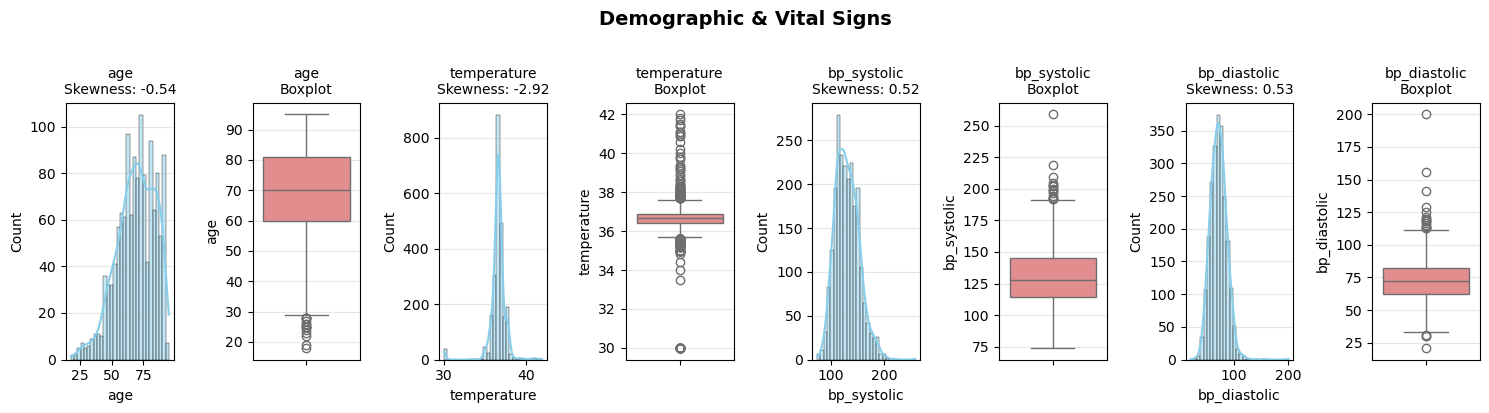

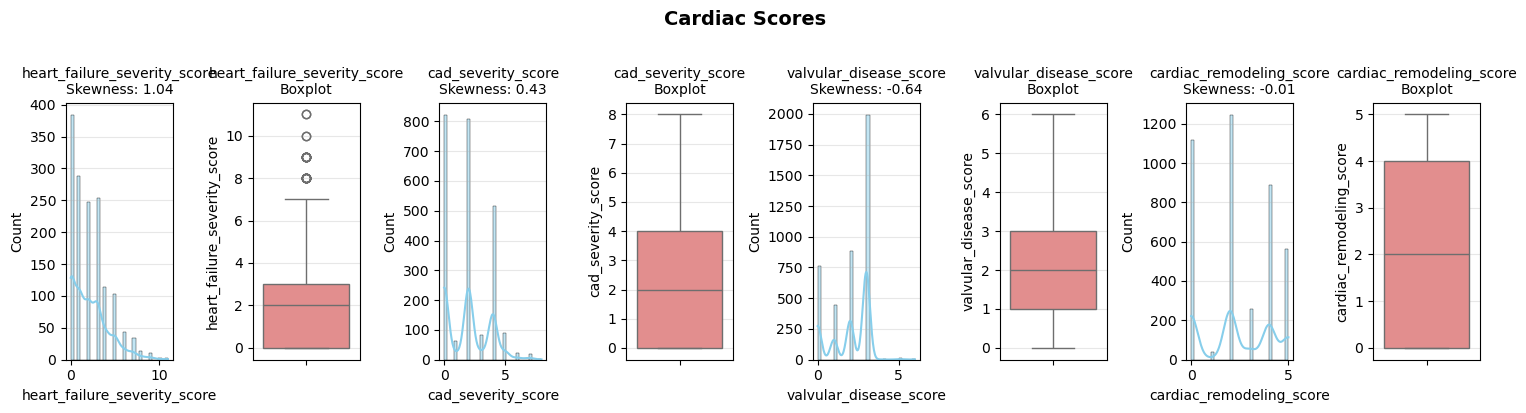

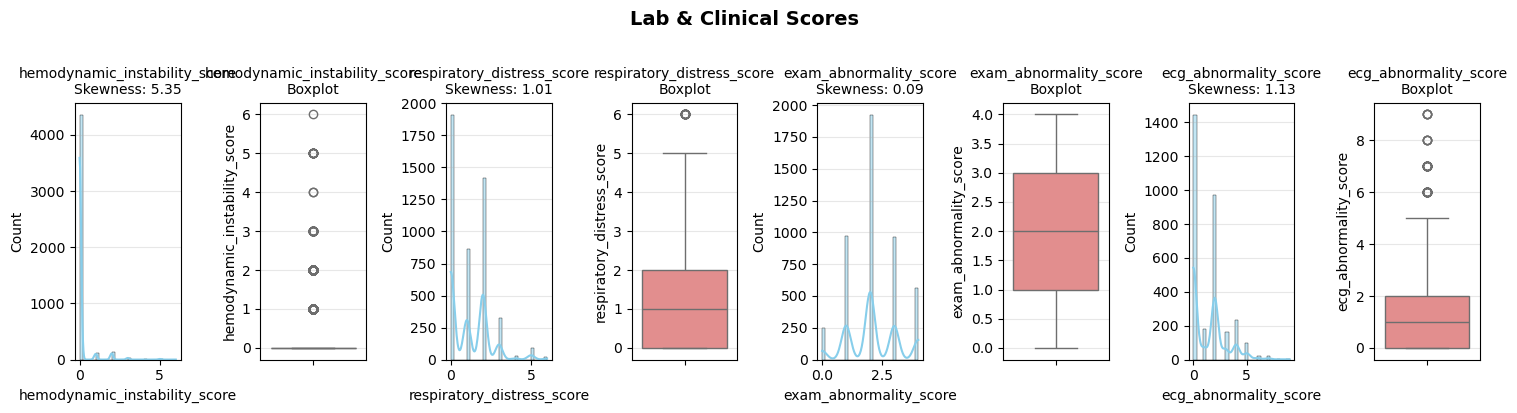

In [53]:
demographic_features = ['age', 'temperature', 'bp_systolic', 'bp_diastolic']
cardiac_features = ['heart_failure_severity_score', 'cad_severity_score', 
                   'valvular_disease_score', 'cardiac_remodeling_score']
lab_features = ['hemodynamic_instability_score', 'respiratory_distress_score',
               'exam_abnormality_score', 'ecg_abnormality_score']

feature_groups = {
    'Demographic & Vital Signs': demographic_features,
    'Cardiac Scores': cardiac_features,
    'Lab & Clinical Scores': lab_features
}

plot_feature_distributions(df_cleaned, feature_groups)


In [55]:
skewness = df_cleaned[features_cols].skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()

print(f"Features with skewness > 1: {len(skewed_features)}")
print("\nSkewness per feature:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

Features with skewness > 1: 8

Skewness per feature:
hemodynamic_instability_score    5.352184
respiratory_rate                 4.818660
ct_complications_score           1.153781
ecg_abnormality_score            1.127507
heart_failure_severity_score     1.036882
respiratory_distress_score       1.012435
oxygen_saturation               -1.296022
temperature                     -2.924007
dtype: float64


### Interquartile Range for detecting outliers

In [56]:
for feat in skewed_features:
    Q1, Q3 = df_cleaned[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_cleaned[feat] = df_cleaned[feat].clip(lower, upper)

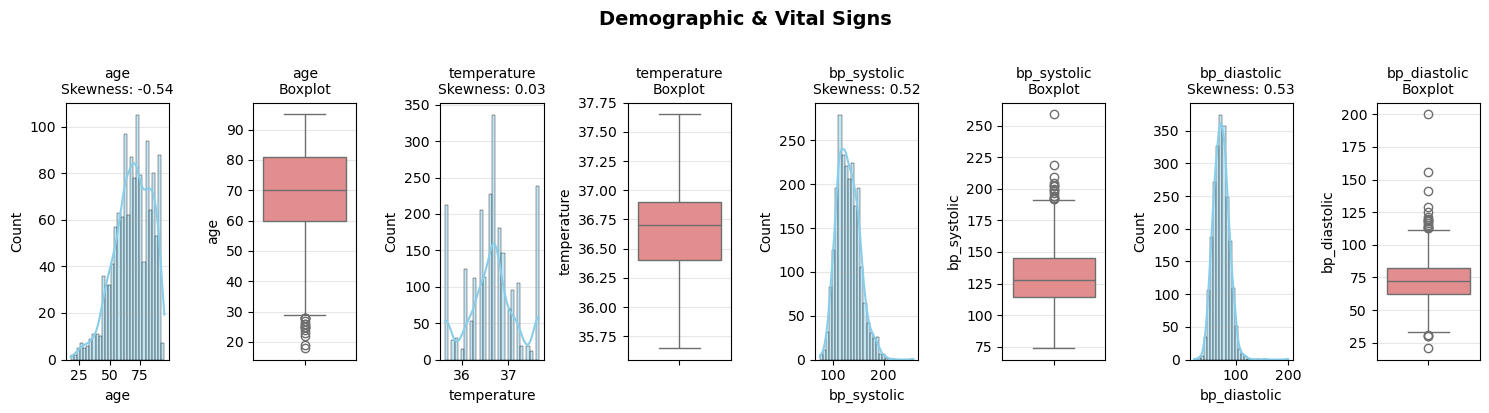

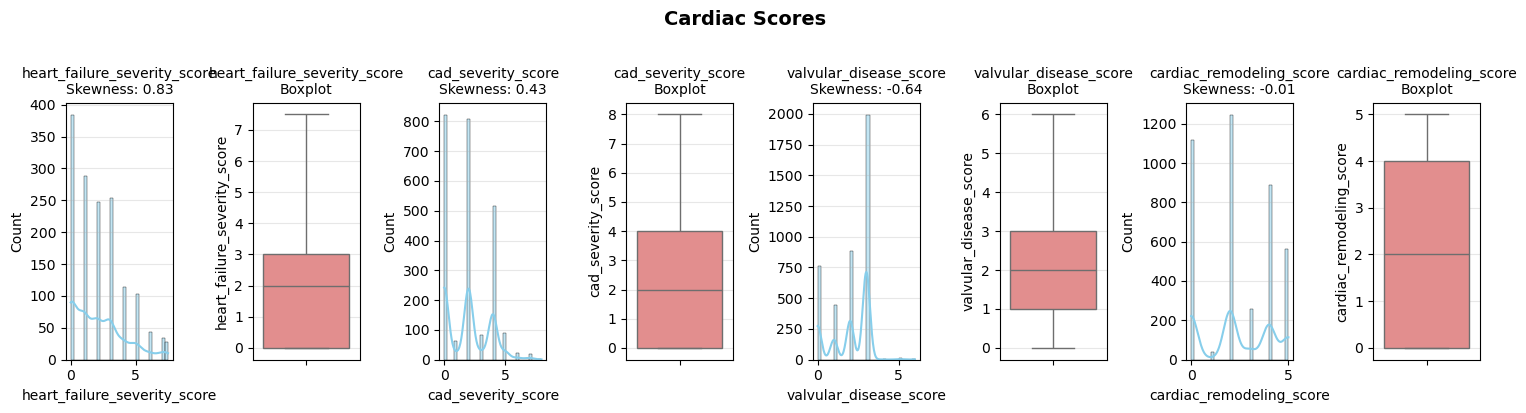

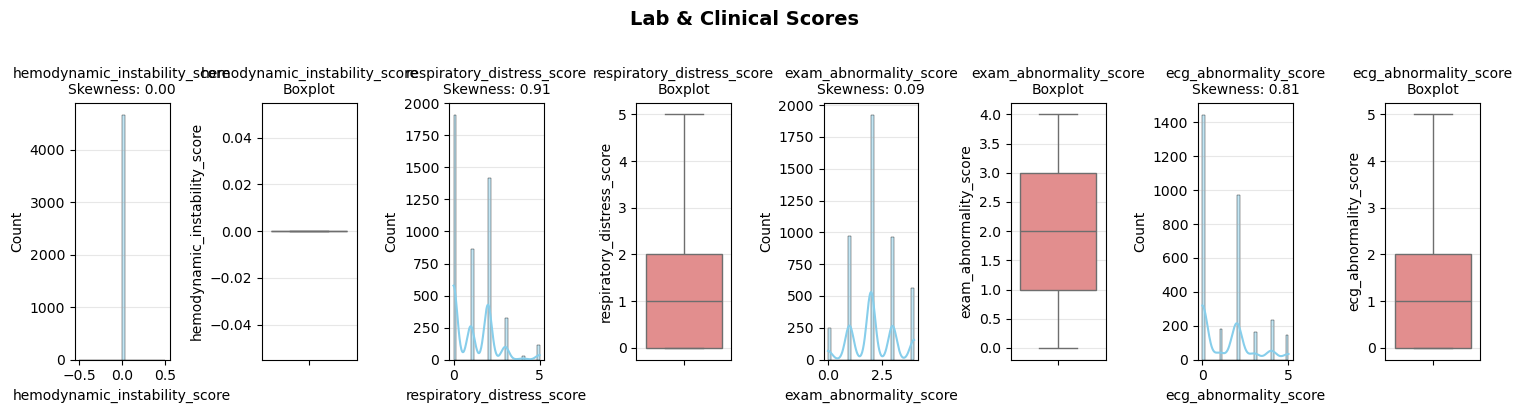

In [57]:
plot_feature_distributions(df_cleaned, feature_groups)

In [59]:
skewness = df_cleaned[features_cols].skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()

print(f"Features with skewness > 1: {len(skewed_features)}")
print("\nSkewness per feature:")
print(skewness[abs(skewness) > 1].sort_values(ascending=False))

Features with skewness > 1: 1

Skewness per feature:
ct_complications_score    1.039533
dtype: float64


In [47]:
df_cleaned.to_csv(Path().resolve().parent / 'Features' / 'heart_diagnoses_features.csv', index=False)
print(f" - Admissions: {len(df_cleaned)}")
print(f" - Unique patients: {df_cleaned['subject_id'].nunique()}")
print(f" - Features per admission: {df_cleaned.shape[1]}")

 - Admissions: 4660
 - Unique patients: 4202
 - Features per admission: 19
